# Sanity Check: Imports + Data + Caches

This notebook checks that core imports work, one patient loads, and cached outputs can be read.
It does not recompute missing caches.

In [1]:
%matplotlib inline
from lrgsglib.config.funcs import move_to_rootf
move_to_rootf(pathname="lrgeegfc")
from lrg_eegfc.notebook import *

Current working directory: /home/opisthofulax/Documents/research+/brain_network/lrg_eegfc


In [2]:
DATA_ROOT = Path('data/stereoeeg_patients')
patients = list_patients(DATA_ROOT)
patients

['Pat_02', 'Pat_03', 'Pat_05', 'Pat_06', 'Pat_07', 'Pat_08']

In [3]:
def _pick_band_phase_from_cache(files, marker):
    for path in files:
        name = path.name
        if marker not in name:
            continue
        prefix = name.split(marker)[0].rstrip('_')
        for phase in PHASE_LABELS:
            suffix = f'_{phase}'
            if prefix.endswith(suffix):
                band = prefix[: -len(suffix)]
                return band, phase
    return None, None

assert patients, 'No patients found under data/stereoeeg_patients'
patient = patients[0]

corr_cache_dir = Path('data/corr_cache') / patient
msc_cache_dir = Path('data/msc_cache') / patient
lrg_cache_dir = Path('data/lrg_cache') / patient

corr_files = sorted(corr_cache_dir.glob('*.npy'))
msc_files = sorted(msc_cache_dir.glob('*.npy'))
lrg_files = sorted(lrg_cache_dir.glob('*.npz'))

band, phase = _pick_band_phase_from_cache(corr_files, '_corr_')
if band is None:
    band, phase = _pick_band_phase_from_cache(msc_files, '_msc_')
if band is None:
    band = next(iter(BRAIN_BANDS.keys()))
    phase = PHASE_LABELS[0]

(patient, phase, band, len(corr_files), len(msc_files), len(lrg_files))

('Pat_02', 'rsPost', 'alpha', 73, 54, 48)

In [4]:
dataset = load_patient_dataset_robust(patient, DATA_ROOT, phases=[phase])
recording = dataset[phase]
timeseries = recording.timeseries
fs = recording.parameters.get('fs')

(timeseries.shape, fs)

((117, 1350464), 2048.0)

In [5]:
corr_path = get_corr_cache_path(patient, phase, band)
corr = load_corr_matrix(patient, phase, band)

msc_path = get_msc_cache_path(patient, phase, band)
msc = load_msc_matrix(patient, phase, band, sparsify='soft', n_surrogates=200)
if msc is None:
    msc = load_msc_matrix(patient, phase, band, sparsify='none', n_surrogates=0)

cleaned_path = get_cleaned_corr_cache_path(patient, phase, band)
cleaned = load_cleaned_corr_matrix(patient, phase, band)

lrg_path = get_lrg_cache_path(patient, phase, band, 'msc')
lrg = load_lrg_result(patient, phase, band, 'msc')

print('corr cache:', corr_path, 'loaded' if corr is not None else 'missing')
print('msc cache:', msc_path, 'loaded' if msc is not None else 'missing')
print('cleaned corr cache:', cleaned_path, 'loaded' if cleaned is not None else 'missing')
print('lrg cache:', lrg_path, 'loaded' if lrg is not None else 'missing')

corr cache: data/corr_cache/Pat_02/alpha_rsPost_corr_ftype-abs_zdiag-True.npy loaded
msc cache: data/msc_cache/Pat_02/alpha_rsPost_msc_sparsify-none_nperseg-1024.npy loaded
cleaned corr cache: (PosixPath('data/corr_cache/Pat_02/alpha_rsPost_corr_cleaned.npy'), PosixPath('data/corr_cache/Pat_02/alpha_rsPost_corr_cleaned_meta.npz')) loaded
lrg cache: data/lrg_cache/Pat_02/alpha_rsPost_lrg_msc.npz loaded


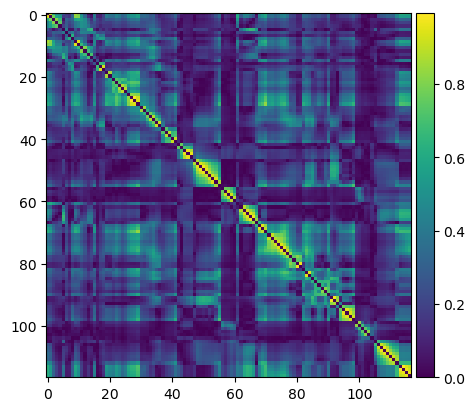

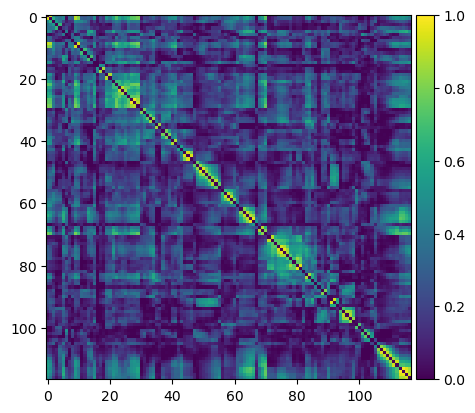

In [6]:
import matplotlib.pyplot as plt
from lrgsglib.plotlib.colorbars import imshow_colorbar_caxdivider

output_dir = Path('data/figures/00_intake')
output_dir.mkdir(parents=True, exist_ok=True)

if corr is not None:
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(corr, cmap='viridis')
    imshow_colorbar_caxdivider(im, ax)
    fig.savefig(output_dir / f'corr_{patient}_{phase}_{band}.pdf', bbox_inches='tight')
    plt.show()

if msc is not None:
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(msc, cmap='viridis', vmin=0, vmax=1)
    imshow_colorbar_caxdivider(im, ax)
    fig.savefig(output_dir / f'msc_{patient}_{phase}_{band}.pdf', bbox_inches='tight')
    plt.show()

In [7]:
if lrg is not None:
    (lrg.n_nodes, lrg.optimal_threshold, lrg.entropy_tau.shape)
else:
    'LRG cache missing for this selection'